In [2]:
# Cell 1 — Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\anura\Downloads\online_retail_II.csv', encoding='latin-1')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst look:")
df.head()

Shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First look:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Cell 2 — Data Cleaning
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Drop rows with no Customer ID (can't do customer analytics without it!)
df = df.dropna(subset=['Customer ID'])

# Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative or zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Convert CustomerID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['Price']

print("\nAfter cleaning:")
print("Shape:", df.shape)
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print("Unique customers:", df['Customer ID'].nunique())
print("Unique countries:", df['Country'].nunique())

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate rows: 34335

After cleaning:
Shape: (805549, 9)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5878
Unique countries: 41


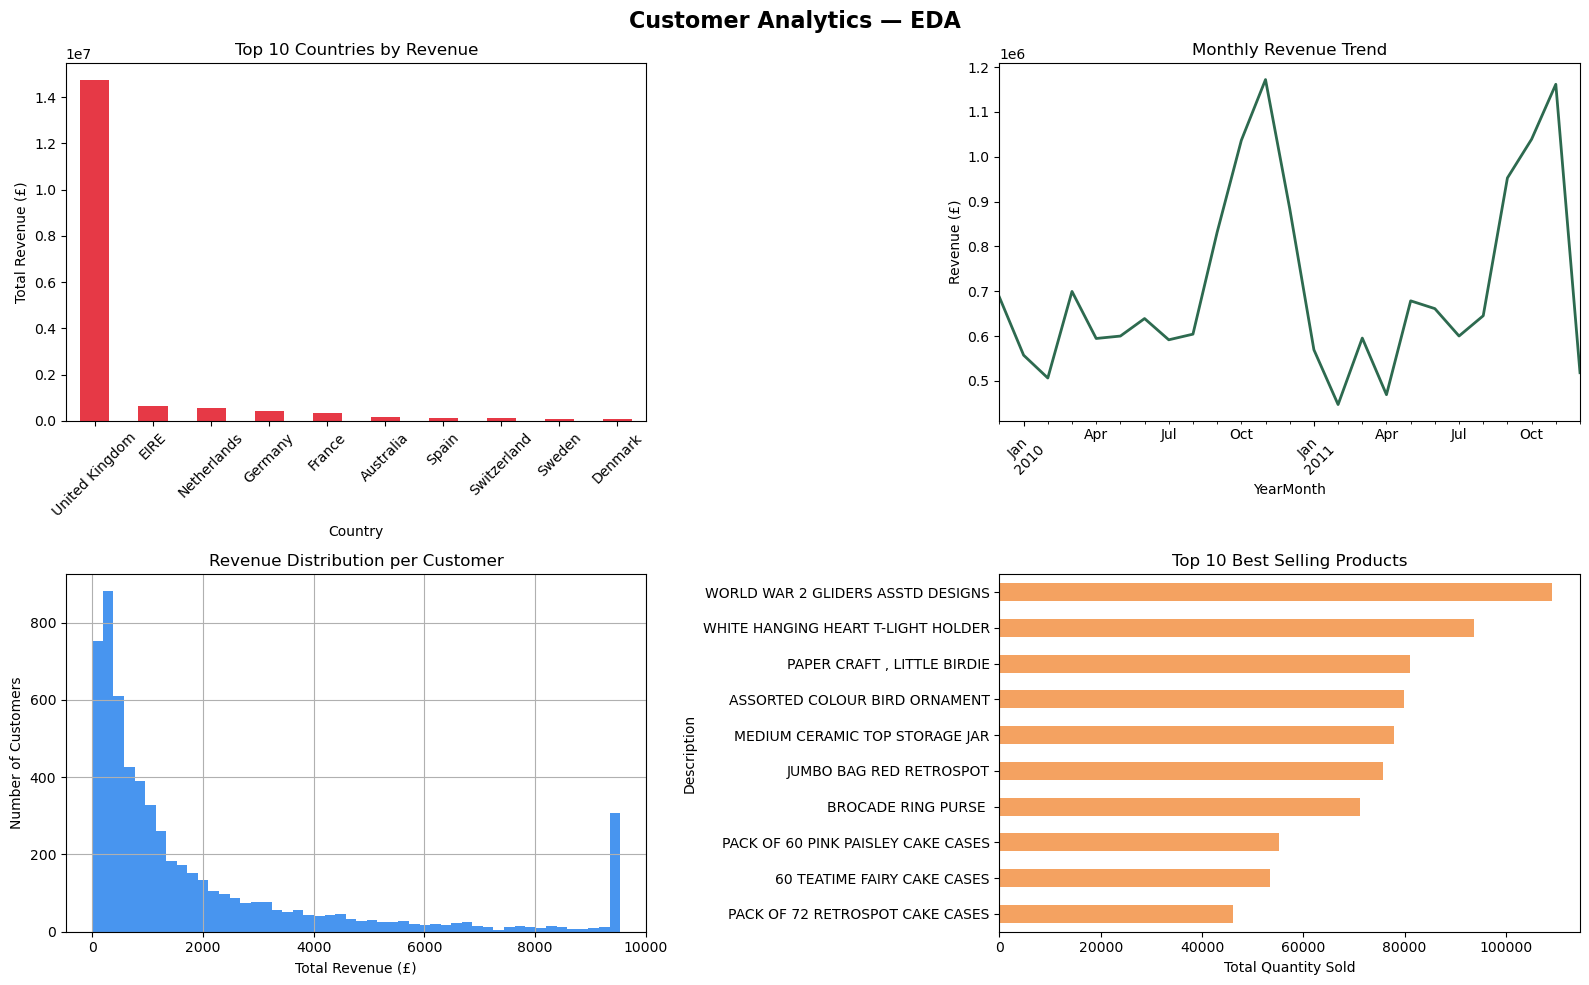

Total Revenue: £17,743,429
Average Order Value: £479.95
Average Revenue per Customer: £3,018.62


In [4]:
# Cell 3 — EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Customer Analytics — EDA', fontsize=16, fontweight='bold')

# 1. Top 10 Countries by Revenue
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
country_revenue.plot(kind='bar', ax=axes[0,0], color='#e63946')
axes[0,0].set_title('Top 10 Countries by Revenue')
axes[0,0].set_ylabel('Total Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Monthly Revenue Trend
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()
monthly_revenue.plot(ax=axes[0,1], color='#2d6a4f', linewidth=2)
axes[0,1].set_title('Monthly Revenue Trend')
axes[0,1].set_ylabel('Revenue (£)')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Revenue Distribution per Customer
customer_revenue = df.groupby('Customer ID')['TotalPrice'].sum()
customer_revenue.clip(upper=customer_revenue.quantile(0.95)).hist(
    bins=50, ax=axes[1,0], color='#4895ef')
axes[1,0].set_title('Revenue Distribution per Customer')
axes[1,0].set_xlabel('Total Revenue (£)')
axes[1,0].set_ylabel('Number of Customers')

# 4. Top 10 Best Selling Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', ax=axes[1,1], color='#f4a261')
axes[1,1].set_title('Top 10 Best Selling Products')
axes[1,1].set_xlabel('Total Quantity Sold')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

# Quick stats
print(f"Total Revenue: £{df['TotalPrice'].sum():,.0f}")
print(f"Average Order Value: £{df.groupby('Invoice')['TotalPrice'].sum().mean():,.2f}")
print(f"Average Revenue per Customer: £{customer_revenue.mean():,.2f}")

In [5]:
# Cell 4 — RFM Analysis
import datetime

# Set reference date (day after last transaction)
reference_date = df['InvoiceDate'].max() + datetime.timedelta(days=1)

# Calculate RFM metrics per customer
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print("RFM Table Sample:")
print(rfm.head(10))
print("\nRFM Statistics:")
print(rfm.describe())

RFM Table Sample:
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40
5        12351      375          1    300.93
6        12352       36         10   2849.84
7        12353      204          2    406.76
8        12354      232          1   1079.40
9        12355      214          2    947.61

RFM Statistics:
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.0000

In [6]:
# Cell 5 — RFM Scoring
# Score each customer 1-5 for each RFM metric
# Recency: lower days = better = higher score
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
# Frequency: higher = better = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
# Monetary: higher = better = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

# Convert to int
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Combined RFM Score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Segment customers based on RFM score
def segment_customer(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost Customers'
    else:
        return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("Customer Segments:")
print(rfm['Segment'].value_counts())
print("\nSegment Revenue:")
print(rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False))

Customer Segments:
Segment
Lost Customers         1523
Champions              1300
Loyal Customers        1134
Potential Loyalists     863
At Risk                 615
New Customers           443
Name: count, dtype: int64

Segment Revenue:
Segment
Champions              1.212812e+07
Loyal Customers        2.603183e+06
At Risk                1.548099e+06
Lost Customers         6.671219e+05
Potential Loyalists    4.022708e+05
New Customers          3.946386e+05
Name: Monetary, dtype: float64


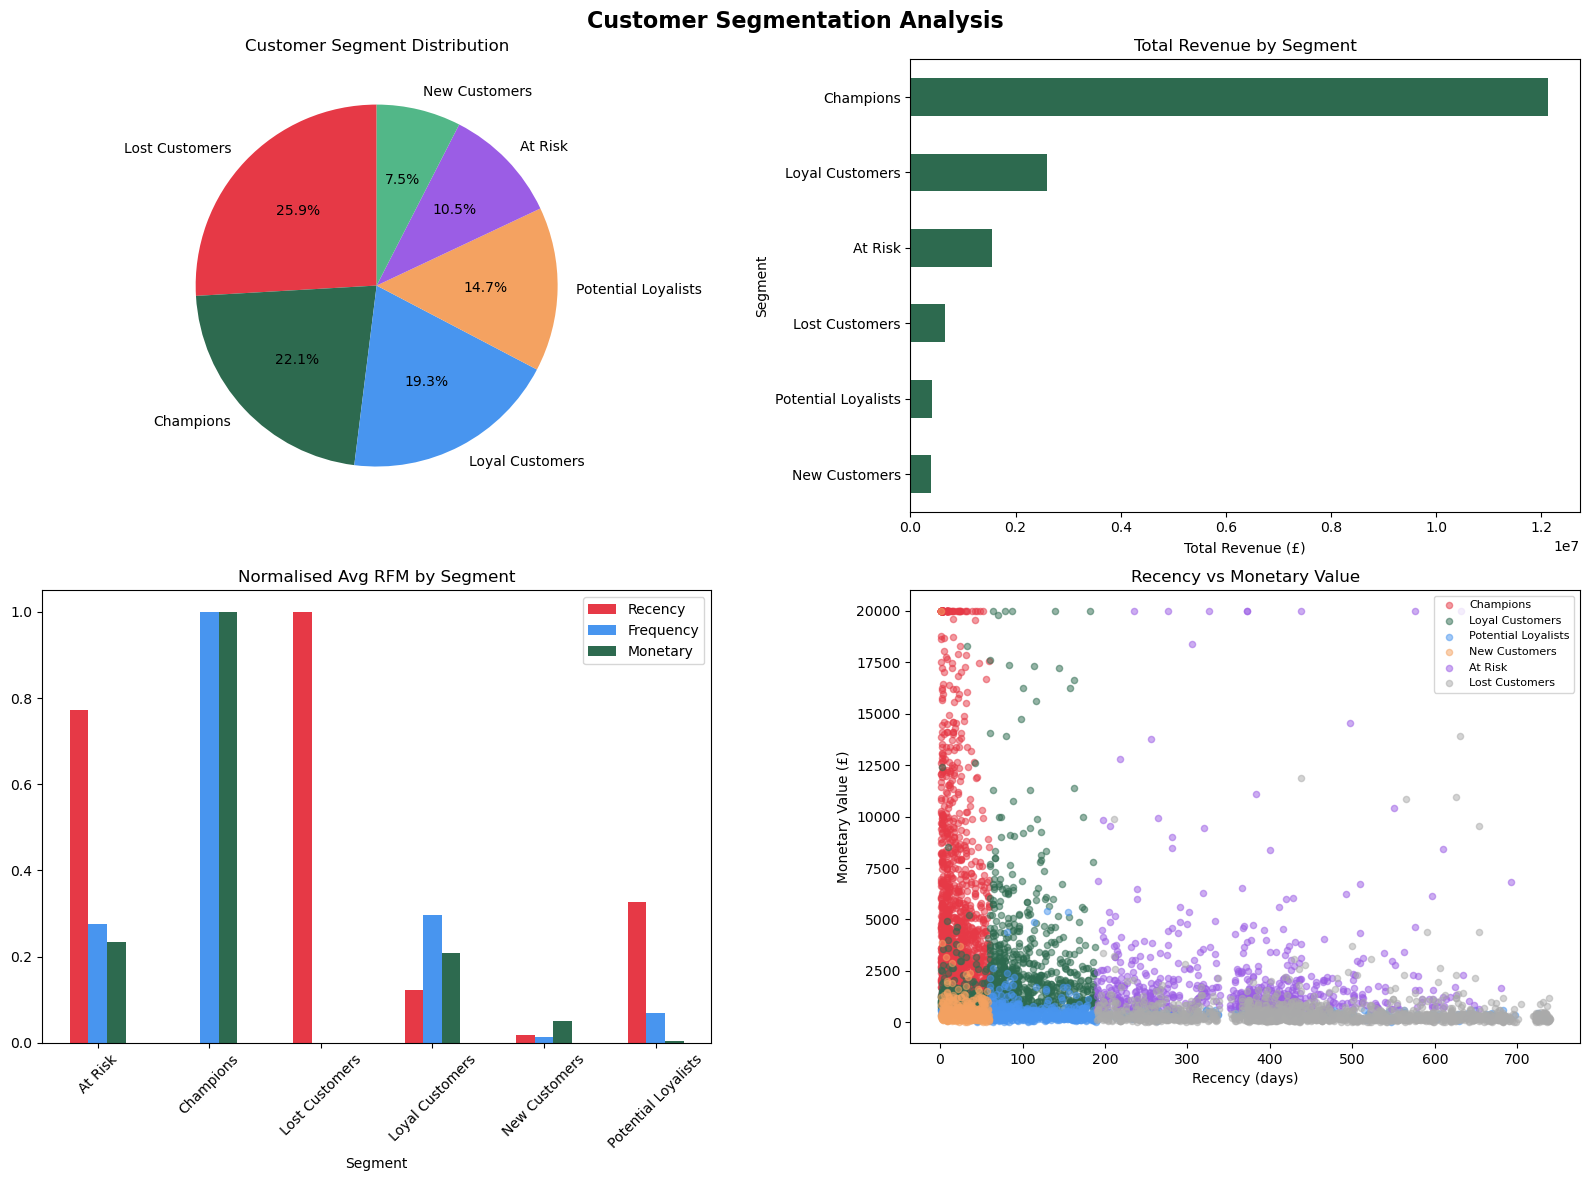

In [7]:
# Cell 6 — Segment Visualisations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Segmentation Analysis', fontsize=16, fontweight='bold')

# 1. Segment Distribution
segment_counts = rfm['Segment'].value_counts()
colors = ['#e63946', '#2d6a4f', '#4895ef', '#f4a261', '#9b5de5', '#52b788']
axes[0,0].pie(segment_counts.values, labels=segment_counts.index, 
              colors=colors, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Customer Segment Distribution')

# 2. Revenue by Segment
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
revenue_by_segment.plot(kind='barh', ax=axes[0,1], color='#2d6a4f')
axes[0,1].set_title('Total Revenue by Segment')
axes[0,1].set_xlabel('Total Revenue (£)')

# 3. Average RFM by Segment
rfm_avg = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
rfm_avg_norm = (rfm_avg - rfm_avg.min()) / (rfm_avg.max() - rfm_avg.min())
rfm_avg_norm.plot(kind='bar', ax=axes[1,0], 
                  color=['#e63946','#4895ef','#2d6a4f'])
axes[1,0].set_title('Normalised Avg RFM by Segment')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['Recency','Frequency','Monetary'])

# 4. Scatter — Recency vs Monetary coloured by segment
segment_colors = {
    'Champions': '#e63946',
    'Loyal Customers': '#2d6a4f', 
    'Potential Loyalists': '#4895ef',
    'New Customers': '#f4a261',
    'At Risk': '#9b5de5',
    'Lost Customers': '#aaaaaa'
}
for segment, color in segment_colors.items():
    mask = rfm['Segment'] == segment
    axes[1,1].scatter(rfm[mask]['Recency'], 
                      rfm[mask]['Monetary'].clip(upper=20000),
                      c=color, label=segment, alpha=0.5, s=20)
axes[1,1].set_title('Recency vs Monetary Value')
axes[1,1].set_xlabel('Recency (days)')
axes[1,1].set_ylabel('Monetary Value (£)')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.show()

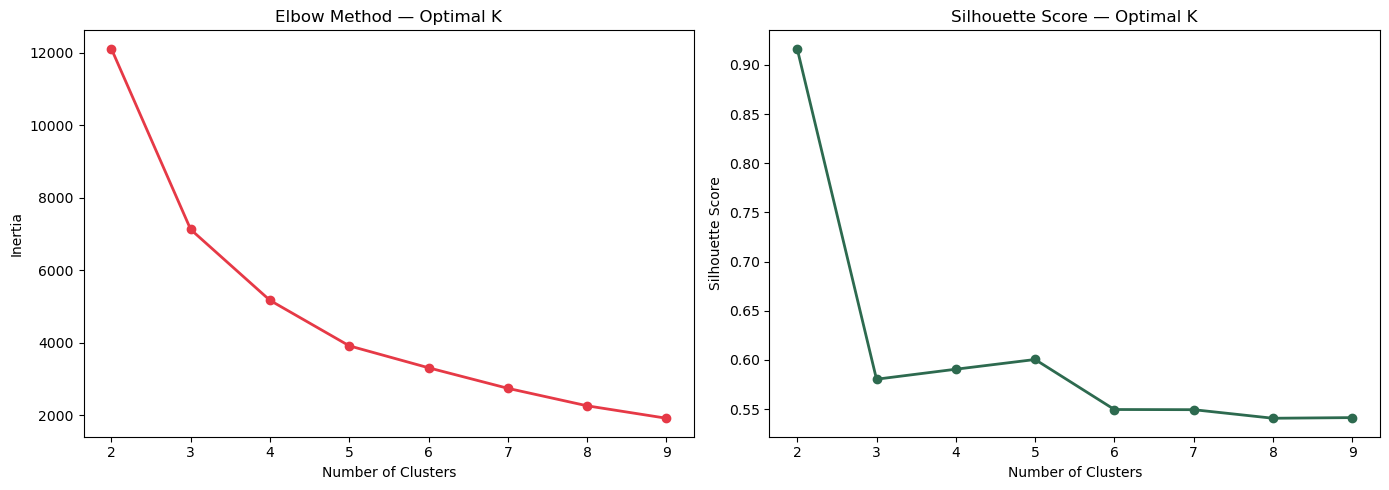

Silhouette Scores:
  k=2: 0.916
  k=3: 0.580
  k=4: 0.591
  k=5: 0.600
  k=6: 0.550
  k=7: 0.549
  k=8: 0.541
  k=9: 0.541


In [8]:
# Cell 7 — K-Means Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Prepare features for clustering
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal number of clusters using Elbow Method
inertia = []
silhouette = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, marker='o', color='#e63946', linewidth=2)
axes[0].set_title('Elbow Method — Optimal K')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette, marker='o', color='#2d6a4f', linewidth=2)
axes[1].set_title('Silhouette Score — Optimal K')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("Silhouette Scores:")
for k, s in zip(k_range, silhouette):
    print(f"  k={k}: {s:.3f}")

In [10]:
# Cell 8 — Apply KMeans k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyse each cluster
cluster_summary = rfm.groupby('Cluster').agg(
    Count     = ('Customer ID', 'count'),
    Recency   = ('Recency', 'mean'),
    Frequency = ('Frequency', 'mean'),
    Monetary  = ('Monetary', 'mean'),
    Total_Rev = ('Monetary', 'sum')
).round(1)

print("Cluster Summary:")
print(cluster_summary)

# Name the clusters based on characteristics
def name_cluster(row):
    if row['Monetary'] > 5000 and row['Frequency'] > 10:
        return '🏆 High Value'
    elif row['Recency'] > 300:
        return '😴 Inactive'
    elif row['Frequency'] > 5:
        return '💚 Loyal Mid-Tier'
    else:
        return '🆕 New / Low Engagement'

cluster_summary['Label'] = cluster_summary.apply(name_cluster, axis=1)
print("\nCluster Labels:")
print(cluster_summary[['Count', 'Label', 'Total_Rev']])

# Map labels back to rfm dataframe
label_map = cluster_summary['Label'].to_dict()
rfm['Cluster_Label'] = rfm['Cluster'].map(label_map)

Cluster Summary:
         Count  Recency  Frequency  Monetary   Total_Rev
Cluster                                                 
0         1998    463.0        2.2     765.2   1528958.4
1         3841     67.0        7.3    3009.4  11559114.8
2           35     25.9      103.7   83086.1   2908012.8
3            4      3.5      212.5  436835.8   1747343.2

Cluster Labels:
         Count             Label   Total_Rev
Cluster                                     
0         1998        😴 Inactive   1528958.4
1         3841  💚 Loyal Mid-Tier  11559114.8
2           35      🏆 High Value   2908012.8
3            4      🏆 High Value   1747343.2


In [12]:
# Cell 10 — Business Recommendations
print("""
╔══════════════════════════════════════════════════════════════════╗
║         CUSTOMER ANALYTICS — BUSINESS RECOMMENDATIONS           ║
╚══════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW
──────────────────────────────────────────────────────
  Total Customers    : 5,878
  Total Revenue      : £17,743,429
  Date Range         : Dec 2009 – Dec 2011
  Countries          : 41

🎯 CUSTOMER SEGMENTS (RFM Analysis)
──────────────────────────────────────────────────────
  Champions          : 1,300 customers → £12.1M revenue (74%)
  Loyal Customers    : 1,134 customers → £2.6M revenue
  At Risk            : 615  customers → £1.5M revenue
  Lost Customers     : 1,523 customers → £667k revenue
  New Customers      : 443  customers → £394k revenue

🔮 K-MEANS CLUSTERS
──────────────────────────────────────────────────────
  👑 VIP Whales      : 4 customers   → £1.7M (avg £436k each!)
  🏆 High Value      : 35 customers  → £2.9M (avg £83k each)
  💚 Loyal Mid-Tier  : 3,841 customers → £11.6M
  😴 Inactive        : 1,998 customers → £1.5M

💡 STRATEGIC RECOMMENDATIONS
──────────────────────────────────────────────────────
  1. VIP PROTECTION PROGRAMME
     4 whale customers generate £1.7M revenue.
     Assign dedicated account managers immediately.
     Any churn here = catastrophic revenue loss.

  2. CHAMPION RETENTION
     1,300 champions drive 74% of revenue.
     Offer exclusive loyalty rewards, early access
     to new products, and personalised discounts.

  3. AT-RISK REACTIVATION
     615 customers worth £1.5M showing signs of leaving.
     Launch targeted win-back campaign within 30 days.
     Offer 15-20% discount to re-engage them.

  4. LOST CUSTOMER ANALYSIS
     1,523 customers haven't bought in 300+ days.
     Cost of reactivation likely exceeds value.
     Focus budget on retaining active customers instead.

  5. SEASONAL STRATEGY
     Revenue spikes Oct-Dec every year.
     Pre-load inventory and marketing spend by September.
     Target Champions and Loyal customers first in campaigns.

  6. NEW CUSTOMER CONVERSION
     443 new customers need nurturing.
     Trigger onboarding email sequence after first purchase.
     Goal: convert to Loyal Mid-Tier within 90 days.

💰 REVENUE OPPORTUNITY
──────────────────────────────────────────────────────
  If 20% of At-Risk customers are retained    : +£309,620
  If 10% of Lost customers are reactivated    : +£66,712
  If New customers convert at 30%             : +£118,391
  Total potential revenue recovery            : ~£494,723
""")


╔══════════════════════════════════════════════════════════════════╗
║         CUSTOMER ANALYTICS — BUSINESS RECOMMENDATIONS           ║
╚══════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW
──────────────────────────────────────────────────────
  Total Customers    : 5,878
  Total Revenue      : £17,743,429
  Date Range         : Dec 2009 – Dec 2011
  Countries          : 41

🎯 CUSTOMER SEGMENTS (RFM Analysis)
──────────────────────────────────────────────────────
  Champions          : 1,300 customers → £12.1M revenue (74%)
  Loyal Customers    : 1,134 customers → £2.6M revenue
  At Risk            : 615  customers → £1.5M revenue
  Lost Customers     : 1,523 customers → £667k revenue
  New Customers      : 443  customers → £394k revenue

🔮 K-MEANS CLUSTERS
──────────────────────────────────────────────────────
  👑 VIP Whales      : 4 customers   → £1.7M (avg £436k each!)
  🏆 High Value      : 35 customers  → £2.9M (avg £83k each)
  💚 Loyal Mid-Tie